# Introduccion a la Bioinformatica - Notebook de desafios

Este notebook consolida, en lectura secuencial, tus respuestas de los desafios I a VIII y una prueba rapida del codigo cuando corresponde.

Sugerencia de uso: leer cada seccion y ejecutar la celda de codigo inmediata para validar la implementacion.

In [29]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo = cwd if (cwd / "intro_biologia").exists() else cwd.parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

print("Repo detectado:", repo)

Repo detectado: D:\repos\intro-bio-inf-unq


## Desafio I

**Consigna:** buscar un ejemplo de macromoleculas que almacenen informacion sobre la identidad de un organismo.

**Respuesta:**
El ADN y el ARN son ejemplos de macromoleculas que almacenan informacion sobre la identidad de los organismos.

## Desafio II

**Consigna:** proponer una forma de expresar la informacion contenida en la estructura primaria de las proteinas usando tipos de datos de programacion.

**Respuesta:**
Se puede modelar como una lista ordenada de aminoacidos.

La estructura primaria se representa con la clase `Proteina` y elementos `Aminoacido`.
En la celda siguiente se prueba creacion, visualizacion y masa total de una proteina.

In [30]:
from intro_biologia.aminoacido import Aminoacido
from intro_biologia.desafio2 import Proteina

proteina_demo = Proteina(
    "Prueba",
    [Aminoacido.metionina(), Aminoacido.alanina(), Aminoacido.cisteina(), Aminoacido.lisina()],
)

print("Estructura primaria:", proteina_demo.mostrar_estructura_primaria())
print("Masa total aproximada:", round(proteina_demo.calcular_masa_total(), 2))

Estructura primaria: NH2-Met-Ala-Cis-Lis-COOH
Masa total aproximada: 451.62


## Desafio III

**Consigna:** en que tipo de datos se puede expresar la estructura terciaria proteica.

**Respuesta:**
Se puede utilizar una matriz N x 3 para modelar las posiciones de cada aminoacido en el espacio 3D.

Se usa `Residuo3D` + `EstructuraTerciaria`, que permite recuperar tanto la secuencia como la matriz de coordenadas.
La celda siguiente lo demuestra con un ejemplo pequeno.

In [31]:
from intro_biologia.desafio3 import Residuo3D, EstructuraTerciaria

residuos = [
    Residuo3D(Aminoacido.alanina(), 0.0, 0.0, 0.0),
    Residuo3D(Aminoacido.valina(), 3.8, 0.0, 0.0),
    Residuo3D(Aminoacido.leucina(), 7.6, 0.0, 0.0),
]

estructura = EstructuraTerciaria(residuos)
print("Secuencia primaria recuperada:", [aa.simbolo for aa in estructura.obtener_secuencia_primaria()])
print("Matriz coordenadas:")
for fila in estructura.obtener_matriz_coordenadas():
    print(fila)

Secuencia primaria recuperada: ['A', 'V', 'L']
Matriz coordenadas:
[0.0, 0.0, 0.0]
[3.8, 0.0, 0.0]
[7.6, 0.0, 0.0]


## Desafio IV

**Consigna:** contribuciones de Rosalind Franklin y que ensena su historia sobre la ciencia.

**Respuesta:**
En primera instancia si bien desde joven mostro aptitudes para la ciencia, su propio padre fue detractora de que se dedicara a la investigación por el hecho de ser mujer. Contribuyo en el descubrimiento de la estructura helicoidal del ADN mediante la toma de imagen de difracción de rayos X. Logro por el cual no fue reconocida como deberia, ya que fue traicionada por Maurice Winkins quien dio acceso sin permiso a las investigaciones y descubrimientos hechos por Rosalind a otros investigadores que practicamente se robaron todo el credito.

Tambien contribuyo a el conocimiento de la estructura del Virus del Mosaico del Tabaco (TMV) y la polio respectivamente, trabajo el cual fue completado de forma postuma por su equipo de trabajo.

Murio con tan solo 37 años a causa de un cancer (relacionado con la exposición constante a los rayos X).

## Desafio V

**Consigna:** escribir un script en Python que prediga estructura secundaria por residuo como H/B/L.

**Respuesta:**
Se implemento un CLI para facilitar pruebas de entrada/salida del algoritmo de prediccion.

**CLI (resumen breve)**
Uso:
`python -m intro_biologia.cli [-h] (-i INPUT | -s SECUENCIA | --stdin) [--id ID] [-f {texto,fasta,tsv,json}] [-o OUTPUT]`

Opciones principales:
- `-i, --input`: archivo FASTA o secuencia cruda.
- `-s, --secuencia`: secuencia directa.
- `--stdin`: lectura desde entrada estandar.
- `--id`: identificador para secuencia directa.
- `-f, --formato`: texto, fasta, tsv o json.
- `-o, --output`: guarda salida en archivo.

En las dos celdas siguientes se hace una prueba rapida con secuencia directa y con FASTA local.

In [40]:
from intro_biologia.desafio5 import ChouFasmanPredictor

predictor = ChouFasmanPredictor()
# Secuencia mas interesante: region helicoidal, region beta y cola tipo loop
secuencia = "AELMQKRAELMQKVIYCFWTVIYGGPNDSS"
prediccion = predictor.predecir(secuencia)
estructura = prediccion.secondary_structure_string

print("Secuencia: ", secuencia)
print("Estructura:", estructura)

Secuencia:  AELMQKRAELMQKVIYCFWTVIYGGPNDSS
Estructura: HHHHHHHHHHHHBBBBBBBBBBLLLLLLLL


In [41]:
from intro_biologia.cli import _leer_archivo_texto, _parsear_fasta

ruta_fasta = repo / "ejemplos" / "proteina_mixta_unica.fasta"
texto = _leer_archivo_texto(ruta_fasta)
registros = _parsear_fasta(texto)

for identificador, sec in registros:
    estructura = predictor.predecir(sec).secondary_structure_string
    print(identificador)
    print(sec)
    print(estructura)
    print()

prot_mixta_unica
AELMQKRAELMQKVIYCFWTVIYGGPNDSS
HHHHHHHHHHHHBBBBBBBBBBLLLLLLLL



## Desafio VI

**Consigna:** que hace distintos a dos individuos de una especie y como corroborarlo computacionalmente.

**Respuesta:**
Lo que hace distintos a dos individuos son, principalmente, sus secuencias de aminoacidos (proteoma) y de nucleotidos (genoma).

**Idea del metodo computacional:**
Comparar posicion por posicion cada secuencia homologable y registrar en una tabla todas las diferencias detectadas.

La celda siguiente ejecuta una version simple de ese reporte de mutaciones.

In [42]:
from intro_biologia.desafio6 import comparar_individuos_simple

individuo_a = {
    "genoma": ["ATCGGTA", "GGCTAG"],
    "proteoma": ["MLPGLA", "MKWTC"],
}

individuo_b = {
    "genoma": ["ATCCGTA", "GGCTAG"],
    "proteoma": ["MLPGLA", "MKWAC"],
}

print(comparar_individuos_simple(individuo_a, individuo_b))

Secuencia    Posicion   Valor_Ind_1     Valor_Ind_2     Info
chr1         4          G               C               Mutación en ADN
prot2        4          T               A               Mutación en Proteína


## Desafio VII

**Consigna (Rosalind):** detectar motivos lineales en proteinas, por ejemplo `N{P}[ST]{P}`.

**Respuesta:**
Se implemento un buscador de motivos con notacion biologica (conjuntos `[]` y exclusiones `{}`), compatible con entradas locales y con IDs de UniProt.

**CLI (resumen breve)**
Uso:
`python -m intro_biologia.desafio7 --ids ID1 ID2 ... --motivo "N{P}[ST]{P}" [--formato texto|json] [-o OUTPUT]`

Opciones principales:
- `--ids`: lista de IDs UniProt.
- `--input`: FASTA local.
- `--secuencia`: secuencia directa.
- `--stdin`: entrada estandar.
- `--motivo`: patron biologico.
- `--formato`: texto o json.
- `-o, --output`: guardar salida.

La celda siguiente muestra una prueba rapida con FASTA local.

In [43]:
from intro_biologia.desafio7 import crear_regex_desde_motivo, buscar_motivo_en_secuencia, parsear_fasta

motivo = "AEL"
regex = crear_regex_desde_motivo(motivo)

ruta = repo / "ejemplos" / "tres_proteinas.fasta"
registros = parsear_fasta(ruta.read_text(encoding="utf-8"))

print("Resultados de búsqueda para el motivo:", motivo)

for identificador, secuencia in registros:
    hits = buscar_motivo_en_secuencia(regex, secuencia)
    if hits:
        print(identificador)
        print("Posiciones:", [pos for pos, _ in hits])
        print()

Resultados de búsqueda para el motivo: AEL
prot_helice
Posiciones: [1, 9]

prot_mixta
Posiciones: [1]



## Desafio VIII

**Consigna:** dada la lista de secuencias provista, realizar una representacion Logo.

<Figure size 1600x300 with 0 Axes>

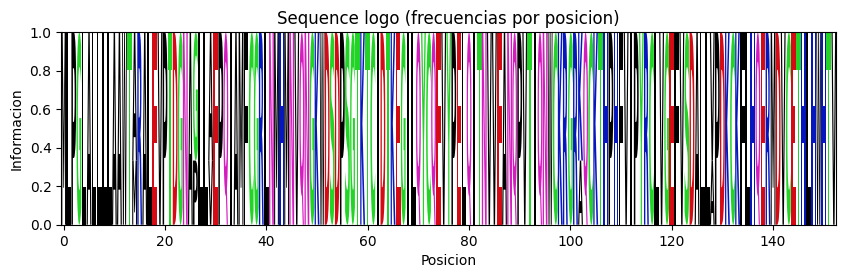

In [49]:
from collections import Counter
import logomaker
import pandas as pd
import matplotlib.pyplot as plt

secuencias = [
    "MLPGLALLLLAAWTMRALEVPTDGNAPLLVEPQIAMFCGRLNMHMNVQNGKWDSDPSGTKTCIDTKEGILQYCQEVYPELQITNVVEANQPVTIQNWCKRGRAQCKTHPHFVIPYRCLVGEFVSDALLAPDKCKFLHQERMDVCETHLHWHTV",
    "MLPGLALLLLAAWTARALEVPTDGNAGLLAEPQIAMFCGRLNMHMNVQNGKWDSDPSGTKTCIDTKEGILQYCQEVYPELQITNVVEANQPVTIQNWCKRGRKQCKTHPHFVIPYRCLVGEFVSDALLVPDKCKFLHQERMDVCETHLHWHTV",
    "MLPGLALLLLAAWTARALEVPTDGNAGLLAEPQIAMFCGRLNMHMNVQNGKWDSDPSGTKTCIDTKEGILQYCQEVYPELQITNVVEANQPVTIQNWCKRGRKQCKTHPHFVIPYRCLVGEFVSDALLVPDKCKFLHQERMDVCETHLHWHTV",
]

conteos = []
for i in range(len(secuencias[0])):
    columna = [s[i] for s in secuencias]
    conteos.append(dict(Counter(columna)))

df = pd.DataFrame(conteos).fillna(0)
df = df.div(df.sum(axis=1), axis=0)

plt.figure(figsize=(16, 3))
_ = logomaker.Logo(df)
plt.title("Sequence logo (frecuencias por posicion)")
plt.xlabel("Posicion")
plt.ylabel("Informacion")
plt.show()